Train : 1940-01-03  →  1991-11-02  (454,348 rows)
Val   : 1991-11-02  →  2009-02-10  (151,449 rows)
Test  : 2009-02-10  →  2026-05-22  (151,450 rows)
[0]	validation_0-rmse:0.16833
[50]	validation_0-rmse:0.12654
[100]	validation_0-rmse:0.12100
[150]	validation_0-rmse:0.11948
[200]	validation_0-rmse:0.11881
[250]	validation_0-rmse:0.11836
[300]	validation_0-rmse:0.11805
[350]	validation_0-rmse:0.11783
[400]	validation_0-rmse:0.11767
[450]	validation_0-rmse:0.11759
[500]	validation_0-rmse:0.11751
[550]	validation_0-rmse:0.11743
[600]	validation_0-rmse:0.11735
[650]	validation_0-rmse:0.11727
[700]	validation_0-rmse:0.11725
[750]	validation_0-rmse:0.11718
[800]	validation_0-rmse:0.11713
[850]	validation_0-rmse:0.11708
[900]	validation_0-rmse:0.11706
[950]	validation_0-rmse:0.11703
[999]	validation_0-rmse:0.11701

Best iteration: 998

XGBOOST 1-HOUR FORECAST

RMSE: 0.23616902063520664
MAE : 0.07002393156290054
R²  : 0.3816203474998474


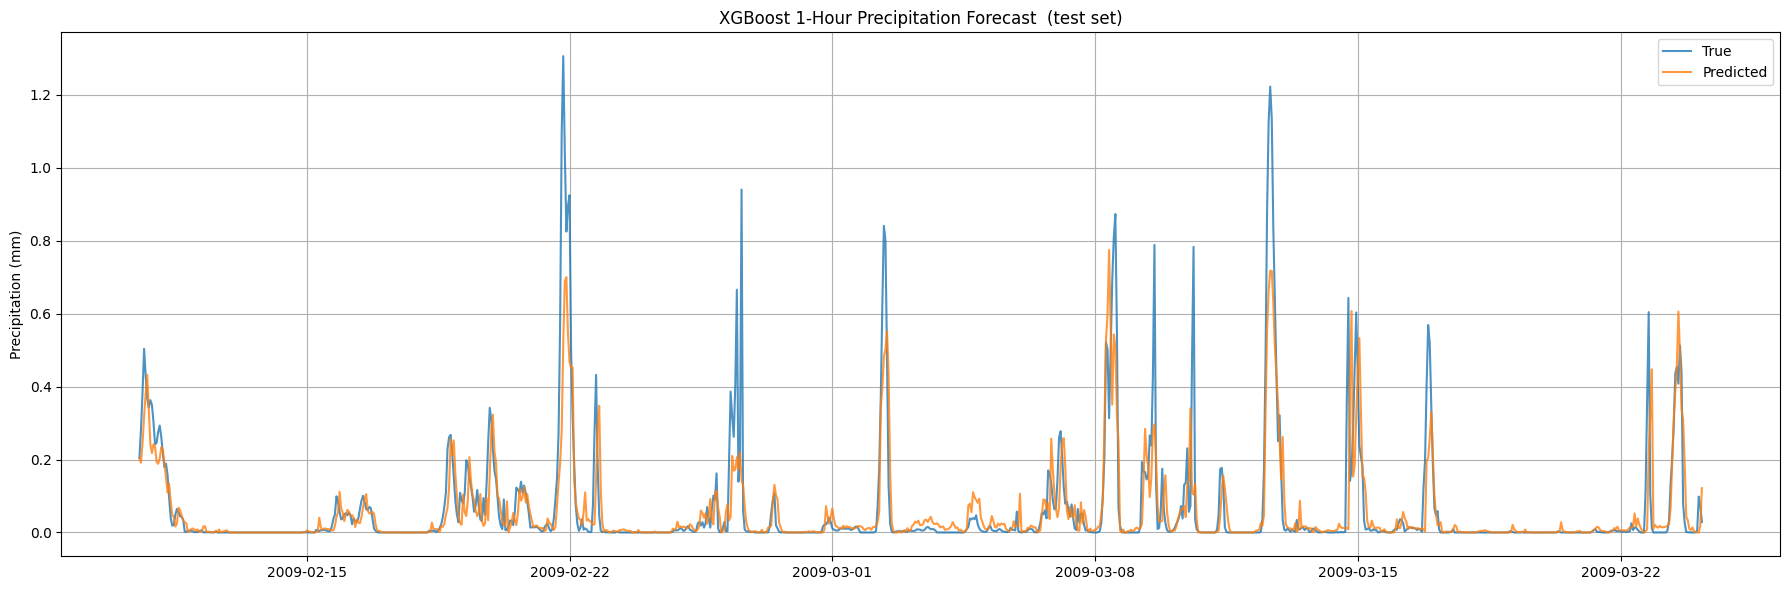

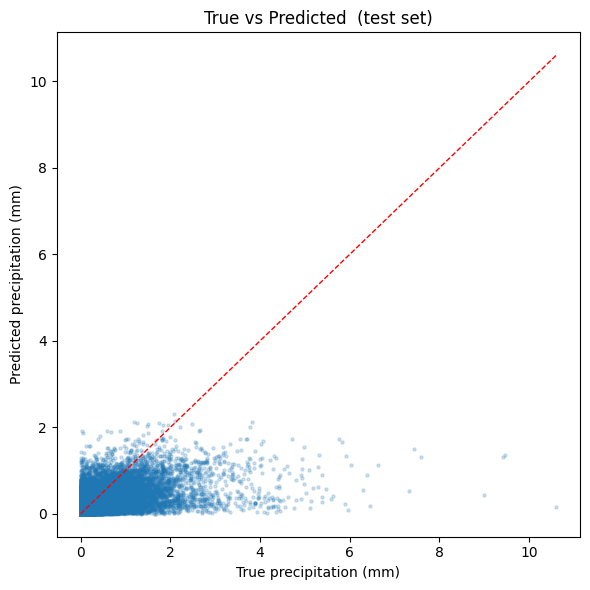

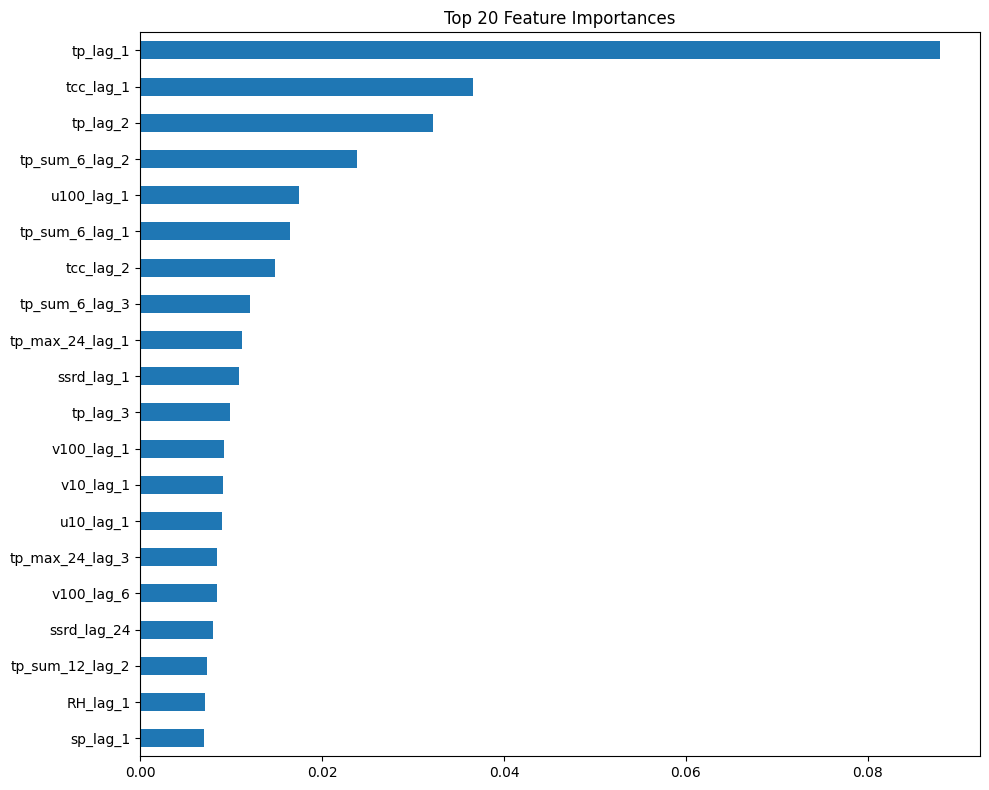

In [3]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

FORECAST_HORIZON = 1          # hours ahead to predict
ROLLING_LAGS     = [1, 2, 3, 6, 12, 24]

ds = xr.open_dataset(
    "single-point-timeseries_all_vars_1940-today_part1.nc"
)

df = ds.to_dataframe()

# Sort index to guarantee chronological order
df = df.sort_index()


df["t2m"] -= 273.15
df["d2m"] -= 273.15

df["tp"] *= 1000

df["wind10"] = np.sqrt(
    df["u10"]**2 +
    df["v10"]**2
)

df["wind100"] = np.sqrt(
    df["u100"]**2 +
    df["v100"]**2
)

df["RH"] = 100 * np.exp(
    (17.625 * df["d2m"]) /
    (243.04 + df["d2m"])
    -
    (17.625 * df["t2m"]) /
    (243.04 + df["t2m"])
)

df["hour"]      = df.index.hour
df["dayofyear"] = df.index.dayofyear

df["hour_sin"] = np.sin(2 * np.pi * df["hour"]      / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"]      / 24)
df["doy_sin"]  = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
df["doy_cos"]  = np.cos(2 * np.pi * df["dayofyear"] / 365.25)


df["tp_sum_6"]    = df["tp"].rolling(6,  min_periods=1).sum()
df["tp_sum_12"]   = df["tp"].rolling(12, min_periods=1).sum()
df["tp_sum_24"]   = df["tp"].rolling(24, min_periods=1).sum()
df["tp_mean_24"]  = df["tp"].rolling(24, min_periods=1).mean()
df["tp_max_24"]   = df["tp"].rolling(24, min_periods=1).max()
df["RH_mean_24"]  = df["RH"].rolling(24, min_periods=1).mean()
df["wind_mean_24"]= df["wind10"].rolling(24, min_periods=1).mean()


features = [
    "t2m", "d2m", "RH",
    "u10", "v10", "u100", "v100",
    "wind10", "wind100",
    "fg10",
    "tcc",
    "sp",
    "blh",
    "strd", "ssrd", "fdir",
    "tp",
    "hour_sin", "hour_cos",
    "doy_sin",  "doy_cos",
    "tp_sum_6", "tp_sum_12", "tp_sum_24",
    "tp_mean_24", "tp_max_24",
    "RH_mean_24",
    "wind_mean_24",
]

df = df[features].dropna()

target = np.log1p(
    df["tp"].shift(-FORECAST_HORIZON)
)


# Guard: max lag must be larger than FORECAST_HORIZON so
# the model never accidentally peeks at the future.
safe_lags = [l for l in ROLLING_LAGS if l >= FORECAST_HORIZON]

lagged_data = {}

for lag in safe_lags:
    for feature in features:
        lagged_data[f"{feature}_lag_{lag}"] = df[feature].shift(lag)

lagged_df = pd.DataFrame(lagged_data, index=df.index)

data = pd.concat(
    [lagged_df, target.rename("target")],
    axis=1
).dropna()

X = data.drop(columns=["target"])
y = data["target"]

n = len(data)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print(f"Train : {X_train.index[0].date()}  →  {X_train.index[-1].date()}  ({len(X_train):,} rows)")
print(f"Val   : {X_val.index[0].date()}  →  {X_val.index[-1].date()}  ({len(X_val):,} rows)")
print(f"Test  : {X_test.index[0].date()}  →  {X_test.index[-1].date()}  ({len(X_test):,} rows)")


model = XGBRegressor(
    n_estimators      = 1000,    # high ceiling; early stopping will cut it
    max_depth         = 6,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    objective         = "reg:squarederror",
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = "hist",
    early_stopping_rounds = 30,  # stop if val loss doesn't improve for 30 rounds
    eval_metric       = "rmse",
)

model.fit(
    X_train, y_train,
    eval_set    = [(X_val, y_val)],
    verbose     = 50,
)

print(f"\nBest iteration: {model.best_iteration}")


def predict(model, X):
    preds_log = model.predict(X)
    preds = np.expm1(preds_log)
    return np.clip(preds, 0, None)

xgb1_preds_val  = predict(model, X_val)
xgb1_preds_test = predict(model, X_test)

xgb1_true_val   = np.expm1(y_val)
xgb1_true_test  = np.expm1(y_test)

xgb1_rmse = np.sqrt(
    mean_squared_error(
        xgb1_true_test,
        xgb1_preds_test
    )
)

xgb1_mae = mean_absolute_error(
    xgb1_true_test,
    xgb1_preds_test
)

xgb1_r2 = r2_score(
    xgb1_true_test,
    xgb1_preds_test
)

print("\nXGBOOST 1-HOUR FORECAST\n")

print("RMSE:", xgb1_rmse)
print("MAE :", xgb1_mae)
print("R²  :", xgb1_r2)


plot_df = pd.DataFrame(
    {
        "True": xgb1_true_test,
        "Predicted": xgb1_preds_test
    },
    index=y_test.index
)

plt.figure(figsize=(18, 6))
plt.plot(plot_df.index[:1000], plot_df["True"][:1000],      label="True",      alpha=0.8)
plt.plot(plot_df.index[:1000], plot_df["Predicted"][:1000], label="Predicted", alpha=0.8)
plt.title(f"XGBoost {FORECAST_HORIZON}-Hour Precipitation Forecast  (test set)")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    xgb1_true_test,
    xgb1_preds_test,
    alpha=0.2,
    s=5
)

lim = max(
    xgb1_true_test.max(),
    xgb1_preds_test.max()
)
plt.plot([0, lim], [0, lim], "r--", linewidth=1)
plt.xlabel("True precipitation (mm)")
plt.ylabel("Predicted precipitation (mm)")
plt.title("True vs Predicted  (test set)")
plt.tight_layout()
plt.show()

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top20.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RAIN_THRESHOLD = 0.1

xgb1_true_rain = (
    xgb1_true_test > RAIN_THRESHOLD
).astype(int)

xgb1_pred_rain = (
    xgb1_preds_test > RAIN_THRESHOLD
).astype(int)

xgb1_accuracy = accuracy_score(
    xgb1_true_rain,
    xgb1_pred_rain
)

xgb1_precision = precision_score(
    xgb1_true_rain,
    xgb1_pred_rain,
    zero_division=0
)

xgb1_recall = recall_score(
    xgb1_true_rain,
    xgb1_pred_rain,
    zero_division=0
)

xgb1_f1 = f1_score(
    xgb1_true_rain,
    xgb1_pred_rain,
    zero_division=0
)

xgb1_cm = confusion_matrix(
    xgb1_true_rain,
    xgb1_pred_rain
)

print("\nXGBOOST 1-HOUR RAIN / NO-RAIN\n")

print("Accuracy :", xgb1_accuracy)
print("Precision:", xgb1_precision)
print("Recall   :", xgb1_recall)
print("F1 Score :", xgb1_f1)

print("\nConfusion Matrix:")
print(xgb1_cm)


XGBOOST 1-HOUR RAIN / NO-RAIN

Accuracy : 0.8920831957741829
Precision: 0.595568173438537
Recall   : 0.7503251579338536
F1 Score : 0.664049331963001

Confusion Matrix:
[[118953  10969]
 [  5375  16153]]


Train : 1940-01-03  →  1991-11-01  (454,334 rows)
Val   : 1991-11-01  →  2009-02-09  (151,445 rows)
Test  : 2009-02-09  →  2026-05-21  (151,445 rows)
[0]	validation_0-rmse:0.17043
[50]	validation_0-rmse:0.16851
[100]	validation_0-rmse:0.16832
[146]	validation_0-rmse:0.16833

Best iteration: 116

XGBOOST 24-HOUR FORECAST

RMSE: 0.2991191220070629
MAE : 0.11074629426002502
R²  : 0.008032798767089844


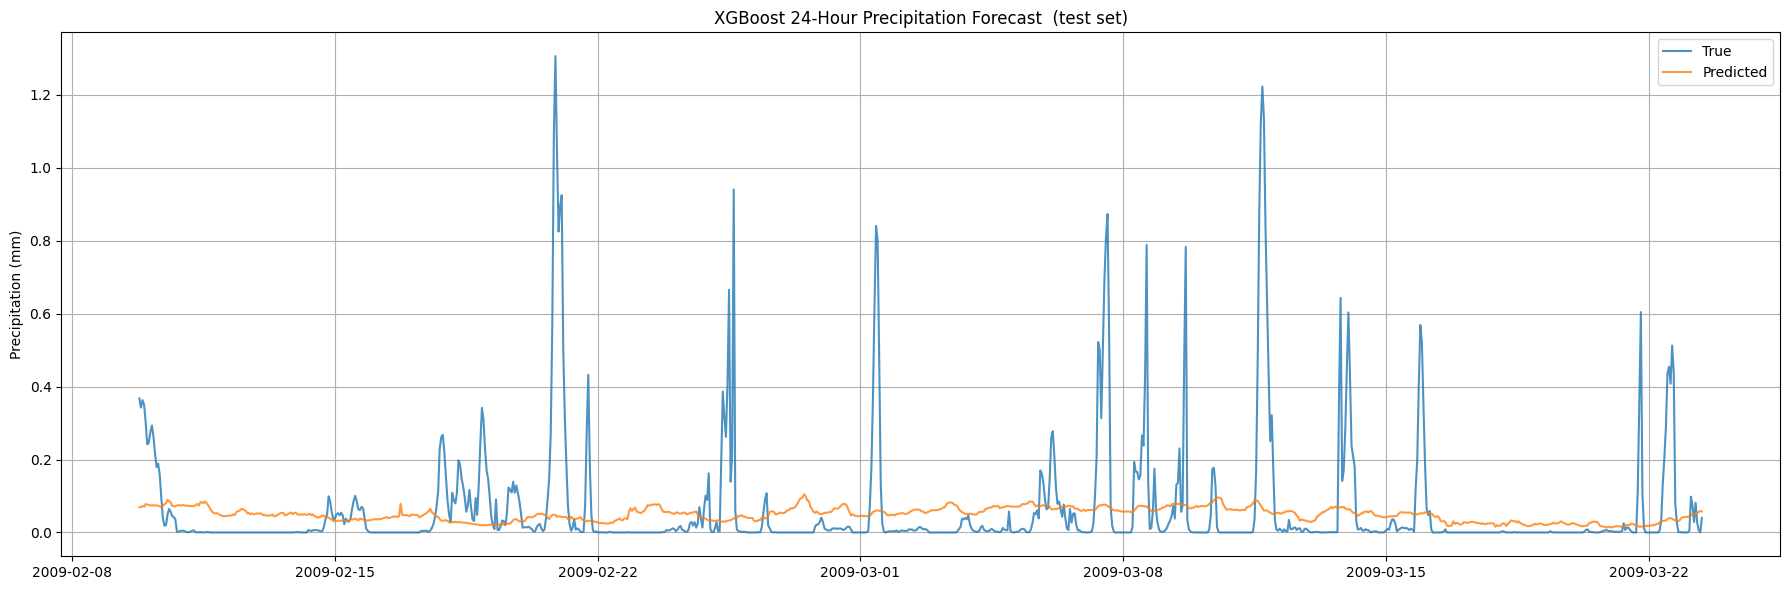

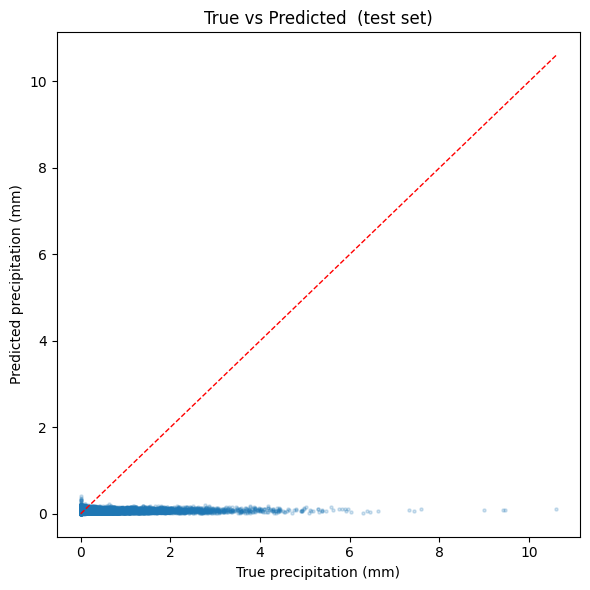

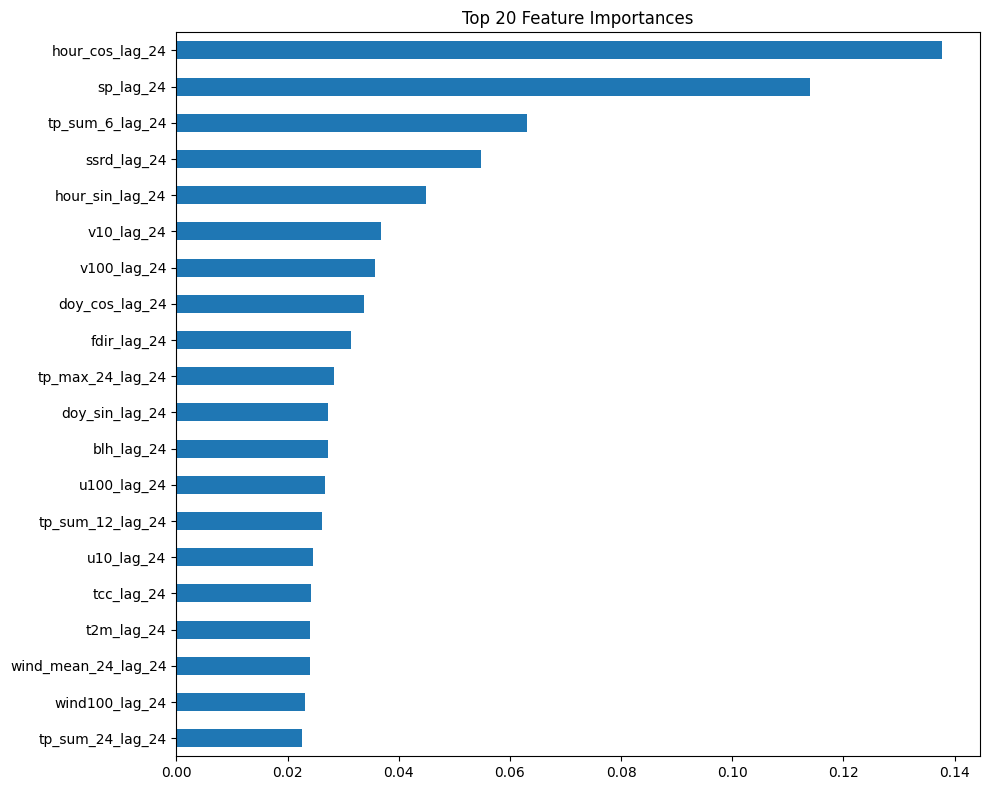

In [8]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


FORECAST_HORIZON = 24          # hours ahead to predict
ROLLING_LAGS     = [1, 2, 3, 6, 12, 24]


ds = xr.open_dataset(
    "single-point-timeseries_all_vars_1940-today_part1.nc"
)

df = ds.to_dataframe()

# Sort index to guarantee chronological order
df = df.sort_index()


df["t2m"] -= 273.15
df["d2m"] -= 273.15

df["tp"] *= 1000

df["wind10"] = np.sqrt(
    df["u10"]**2 +
    df["v10"]**2
)

df["wind100"] = np.sqrt(
    df["u100"]**2 +
    df["v100"]**2
)

df["RH"] = 100 * np.exp(
    (17.625 * df["d2m"]) /
    (243.04 + df["d2m"])
    -
    (17.625 * df["t2m"]) /
    (243.04 + df["t2m"])
)


df["hour"]      = df.index.hour
df["dayofyear"] = df.index.dayofyear

df["hour_sin"] = np.sin(2 * np.pi * df["hour"]      / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"]      / 24)
df["doy_sin"]  = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
df["doy_cos"]  = np.cos(2 * np.pi * df["dayofyear"] / 365.25)


df["tp_sum_6"]    = df["tp"].rolling(6,  min_periods=1).sum()
df["tp_sum_12"]   = df["tp"].rolling(12, min_periods=1).sum()
df["tp_sum_24"]   = df["tp"].rolling(24, min_periods=1).sum()
df["tp_mean_24"]  = df["tp"].rolling(24, min_periods=1).mean()
df["tp_max_24"]   = df["tp"].rolling(24, min_periods=1).max()
df["RH_mean_24"]  = df["RH"].rolling(24, min_periods=1).mean()
df["wind_mean_24"]= df["wind10"].rolling(24, min_periods=1).mean()


features = [
    "t2m", "d2m", "RH",
    "u10", "v10", "u100", "v100",
    "wind10", "wind100",
    "fg10",
    "tcc",
    "sp",
    "blh",
    "strd", "ssrd", "fdir",
    "tp",
    "hour_sin", "hour_cos",
    "doy_sin",  "doy_cos",
    "tp_sum_6", "tp_sum_12", "tp_sum_24",
    "tp_mean_24", "tp_max_24",
    "RH_mean_24",
    "wind_mean_24",
]

df = df[features].dropna()

target = np.log1p(
    df["tp"].shift(-FORECAST_HORIZON)
)

# Guard: max lag must be larger than FORECAST_HORIZON so
# the model never accidentally peeks at the future.
safe_lags = [l for l in ROLLING_LAGS if l >= FORECAST_HORIZON]

lagged_data = {}

for lag in safe_lags:
    for feature in features:
        lagged_data[f"{feature}_lag_{lag}"] = df[feature].shift(lag)

lagged_df = pd.DataFrame(lagged_data, index=df.index)

data = pd.concat(
    [lagged_df, target.rename("target")],
    axis=1
).dropna()

X = data.drop(columns=["target"])
y = data["target"]


n = len(data)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print(f"Train : {X_train.index[0].date()}  →  {X_train.index[-1].date()}  ({len(X_train):,} rows)")
print(f"Val   : {X_val.index[0].date()}  →  {X_val.index[-1].date()}  ({len(X_val):,} rows)")
print(f"Test  : {X_test.index[0].date()}  →  {X_test.index[-1].date()}  ({len(X_test):,} rows)")


model = XGBRegressor(
    n_estimators      = 1000,    # high ceiling; early stopping will cut it
    max_depth         = 6,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    objective         = "reg:squarederror",
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = "hist",
    early_stopping_rounds = 30,  # stop if val loss doesn't improve for 30 rounds
    eval_metric       = "rmse",
)

model.fit(
    X_train, y_train,
    eval_set    = [(X_val, y_val)],
    verbose     = 50,
)

print(f"\nBest iteration: {model.best_iteration}")


def predict(model, X):
    preds_log = model.predict(X)
    preds = np.expm1(preds_log)
    return np.clip(preds, 0, None)

xgb24_preds_val  = predict(model, X_val)
xgb24_preds_test = predict(model, X_test)

xgb24_true_val   = np.expm1(y_val)
xgb24_true_test  = np.expm1(y_test)

xgb24_rmse = np.sqrt(
    mean_squared_error(
        xgb24_true_test,
        xgb24_preds_test
    )
)

xgb24_mae = mean_absolute_error(
    xgb24_true_test,
    xgb24_preds_test
)

xgb24_r2 = r2_score(
    xgb24_true_test,
    xgb24_preds_test
)

print("\nXGBOOST 24-HOUR FORECAST\n")

print("RMSE:", xgb24_rmse)
print("MAE :", xgb24_mae)
print("R²  :", xgb24_r2)


plot_df = pd.DataFrame(
    {
        "True": xgb24_true_test,
        "Predicted": xgb24_preds_test
    },
    index=y_test.index
)

plt.figure(figsize=(18, 6))
plt.plot(plot_df.index[:1000], plot_df["True"][:1000],      label="True",      alpha=0.8)
plt.plot(plot_df.index[:1000], plot_df["Predicted"][:1000], label="Predicted", alpha=0.8)
plt.title(f"XGBoost {FORECAST_HORIZON}-Hour Precipitation Forecast  (test set)")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 6))
plt.scatter(
    xgb24_true_test,
    xgb24_preds_test,
    alpha=0.2,
    s=5
)

lim = max(
    xgb24_true_test.max(),
    xgb24_preds_test.max()
)
plt.plot([0, lim], [0, lim], "r--", linewidth=1)
plt.xlabel("True precipitation (mm)")
plt.ylabel("Predicted precipitation (mm)")
plt.title("True vs Predicted  (test set)")
plt.tight_layout()
plt.show()

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top20.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RAIN_THRESHOLD = 0.1

xgb24_true_rain = (
    xgb24_true_test > RAIN_THRESHOLD
).astype(int)

xgb24_pred_rain = (
    xgb24_preds_test > RAIN_THRESHOLD
).astype(int)

xgb24_accuracy = accuracy_score(
    xgb24_true_rain,
    xgb24_pred_rain
)

xgb24_precision = precision_score(
    xgb24_true_rain,
    xgb24_pred_rain,
    zero_division=0
)

xgb24_recall = recall_score(
    xgb24_true_rain,
    xgb24_pred_rain,
    zero_division=0
)

xgb24_f1 = f1_score(
    xgb24_true_rain,
    xgb24_pred_rain,
    zero_division=0
)

xgb24_cm = confusion_matrix(
    xgb24_true_rain,
    xgb24_pred_rain
)

print("\nXGBOOST 24-HOUR RAIN / NO-RAIN\n")

print("Accuracy :", xgb24_accuracy)
print("Precision:", xgb24_precision)
print("Recall   :", xgb24_recall)
print("F1 Score :", xgb24_f1)

print("\nConfusion Matrix:")
print(xgb24_cm)


XGBOOST 24-HOUR RAIN / NO-RAIN

Accuracy : 0.8240747466076793
Precision: 0.2616387337057728
Recall   : 0.13055800771267945
F1 Score : 0.1741933484176921

Confusion Matrix:
[[121992   7930]
 [ 18713   2810]]


X shape: (757247, 24, 21)
y shape: (757247,)


C:\Users\Vasileios\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 180s 100ms/step - loss: 0.0154 - val_loss: 0.0150
Epoch 2/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 106s 60ms/step - loss: 0.0131 - val_loss: 0.0144
Epoch 3/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 139s 58ms/step - loss: 0.0126 - val_loss: 0.0140
Epoch 4/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 109s 61ms/step - loss: 0.0124 - val_loss: 0.0140
Epoch 5/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 104s 58ms/step - loss: 0.0122 - val_loss: 0.0138
Epoch 6/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 438s 225ms/step - loss: 0.0120 - val_loss: 0.0137
Epoch 7/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 112s 63ms/step - loss: 0.0118 - val_loss: 0.0140
Epoch 8/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 107s 60ms/step - loss: 0.0116 - val_loss: 0.0137
Epoch 9/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 142s 60ms/step - loss: 0.0115 - val_loss: 0.0139
Epoch 10/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 144s 61ms/step - loss: 0.0114 - val_loss: 0.0140

1-HOUR LSTM FORECAST

RMSE: 0.23579497927464263
MAE : 0.06833460181951523
R²  : 0.3835

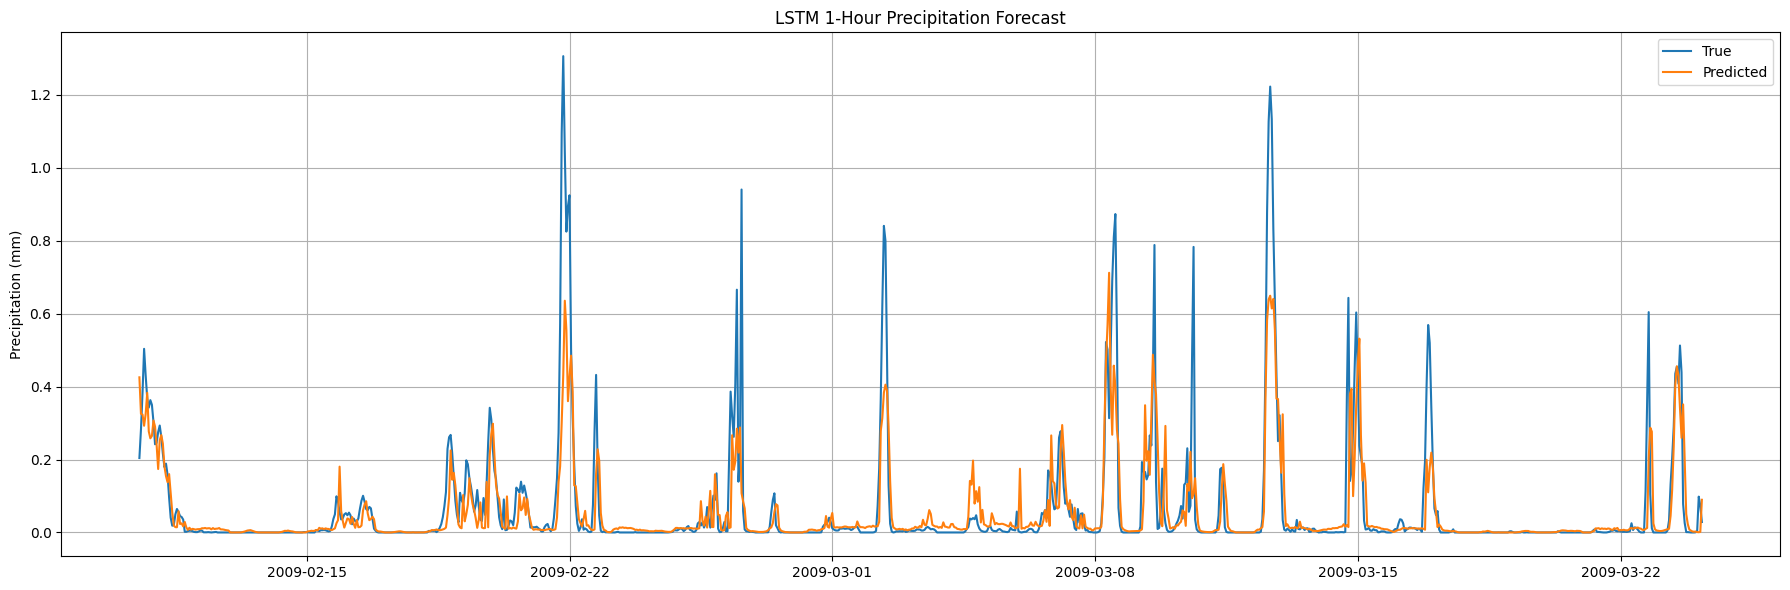

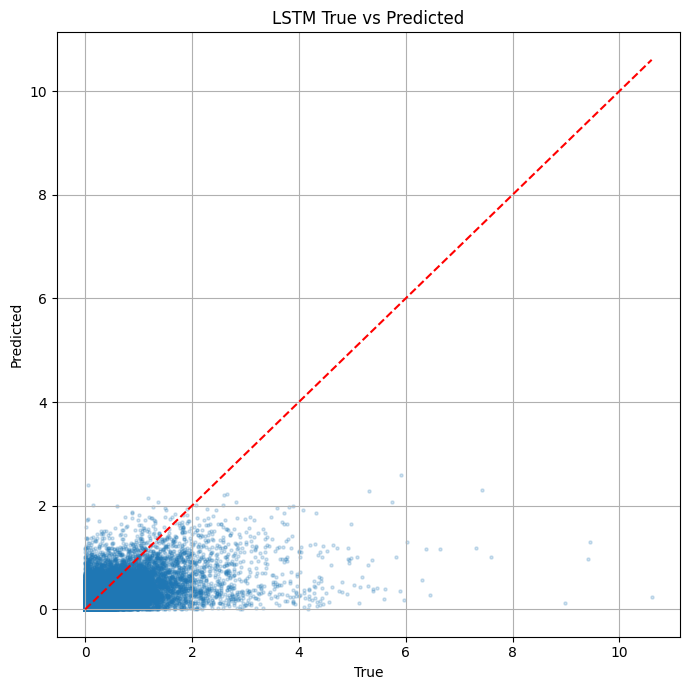

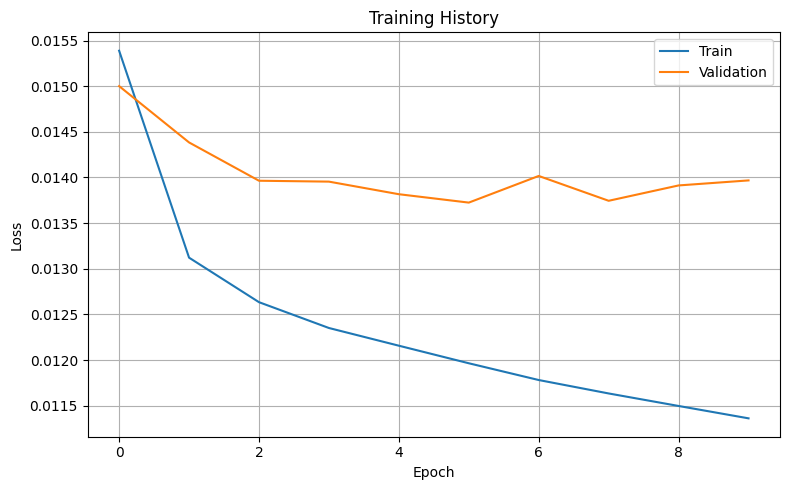

In [11]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


FORECAST_HORIZON = 1
SEQUENCE_LENGTH = 24

ds = xr.open_dataset(
    "single-point-timeseries_all_vars_1940-today_part1.nc"
)

df = ds.to_dataframe().sort_index()

df["t2m"] -= 273.15
df["d2m"] -= 273.15
df["tp"] *= 1000

df["wind10"] = np.sqrt(
    df["u10"]**2 +
    df["v10"]**2
)

df["wind100"] = np.sqrt(
    df["u100"]**2 +
    df["v100"]**2
)

df["RH"] = 100 * np.exp(
    (17.625 * df["d2m"]) /
    (243.04 + df["d2m"])
    -
    (17.625 * df["t2m"]) /
    (243.04 + df["t2m"])
)


df["hour"] = df.index.hour
df["dayofyear"] = df.index.dayofyear

df["hour_sin"] = np.sin(
    2*np.pi*df["hour"]/24
)

df["hour_cos"] = np.cos(
    2*np.pi*df["hour"]/24
)

df["doy_sin"] = np.sin(
    2*np.pi*df["dayofyear"]/365.25
)

df["doy_cos"] = np.cos(
    2*np.pi*df["dayofyear"]/365.25
)


features = [

    "t2m",
    "d2m",
    "RH",

    "u10",
    "v10",
    "u100",
    "v100",

    "wind10",
    "wind100",

    "fg10",

    "tcc",

    "sp",

    "blh",

    "strd",
    "ssrd",
    "fdir",

    "tp",

    "hour_sin",
    "hour_cos",

    "doy_sin",
    "doy_cos"
]

df = df[features].dropna()


target = np.log1p(
    df["tp"].shift(-FORECAST_HORIZON)
)

df["target"] = target

df = df.dropna()


feature_scaler = StandardScaler()

X_scaled = feature_scaler.fit_transform(
    df[features]
)


X = []
y = []

for i in range(SEQUENCE_LENGTH, len(df)):

    X.append(
        X_scaled[
            i-SEQUENCE_LENGTH:i
        ]
    )

    y.append(
        df["target"].iloc[i]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

n = len(X)

train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:]

y_train = y[:train_end]
y_val   = y[train_end:val_end]
y_test  = y[val_end:]


model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(32)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(16, activation="relu")
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse"
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


lstm1_history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=10,

    batch_size=256,

    callbacks=[
        early_stop
    ],

    verbose=1
)


lstm1_preds_log = model.predict(
    X_test,
    verbose=0
).flatten()

lstm1_preds = np.expm1(
    lstm1_preds_log
)

lstm1_true = np.expm1(
    y_test
)

lstm1_preds = np.clip(
    lstm1_preds,
    0,
    None
)


lstm1_rmse = np.sqrt(
    mean_squared_error(
        lstm1_true,
        lstm1_preds
    )
)

lstm1_mae = mean_absolute_error(
    lstm1_true,
    lstm1_preds
)

lstm1_r2 = r2_score(
    lstm1_true,
    lstm1_preds
)

print("\n1-HOUR LSTM FORECAST\n")

print("RMSE:", lstm1_rmse)
print("MAE :", lstm1_mae)
print("R²  :", lstm1_r2)


test_index = df.index[
    SEQUENCE_LENGTH + val_end:
]

plot_df = pd.DataFrame(
    {
        "True": lstm1_true,
        "Predicted": lstm1_preds
    },
    index=test_index
)

plt.figure(
    figsize=(18,6)
)

plt.plot(
    plot_df.index[:1000],
    plot_df["True"][:1000],
    label="True"
)

plt.plot(
    plot_df.index[:1000],
    plot_df["Predicted"][:1000],
    label="Predicted"
)

plt.title(
    "LSTM 1-Hour Precipitation Forecast"
)

plt.ylabel(
    "Precipitation (mm)"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(7,7)
)

plt.scatter(
    lstm1_true,
    lstm1_preds,
    alpha=0.2,
    s=5
)

m = max(
    lstm1_true.max(),
    lstm1_preds.max()
)

plt.plot(
    [0,m],
    [0,m],
    "r--"
)

plt.xlabel(
    "True"
)

plt.ylabel(
    "Predicted"
)

plt.title(
    "LSTM True vs Predicted"
)

plt.grid(True)

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(8,5)
)

plt.plot(
    lstm1_history.history["loss"],
    label="Train"
)

plt.plot(
    lstm1_history.history["val_loss"],
    label="Validation"
)

plt.title(
    "Training History"
)

plt.ylabel(
    "Loss"
)

plt.xlabel(
    "Epoch"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


LSTM 1-HOUR RAIN / NO-RAIN

Accuracy : 0.8984
Precision: 0.6225
Recall   : 0.7250
F1 Score : 0.6698

Confusion Matrix:
[[120456   9466]
 [  5921  15607]]


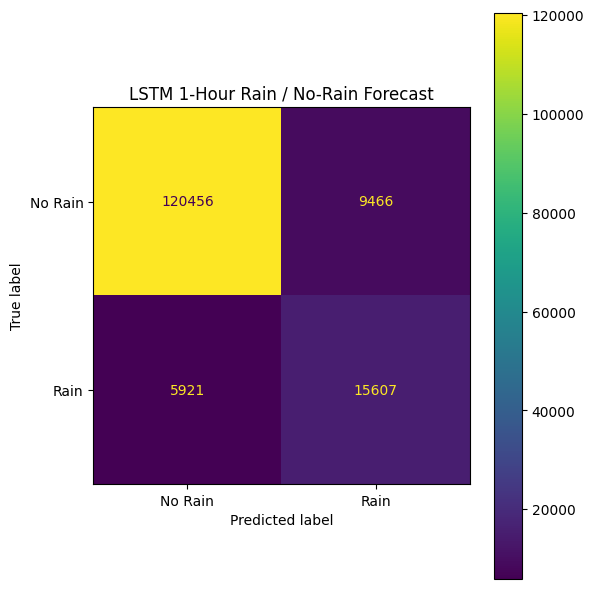

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


RAIN_THRESHOLD = 0.1  # mm

lstm1_true_rain = (
    lstm1_true > RAIN_THRESHOLD
).astype(int)

lstm1_pred_rain = (
    lstm1_preds > RAIN_THRESHOLD
).astype(int)


lstm1_accuracy = accuracy_score(
    lstm1_true_rain,
    lstm1_pred_rain
)

lstm1_precision = precision_score(
    lstm1_true_rain,
    lstm1_pred_rain,
    zero_division=0
)

lstm1_recall = recall_score(
    lstm1_true_rain,
    lstm1_pred_rain,
    zero_division=0
)

lstm1_f1 = f1_score(
    lstm1_true_rain,
    lstm1_pred_rain,
    zero_division=0
)

print("\nLSTM 1-HOUR RAIN / NO-RAIN\n")

print(f"Accuracy : {lstm1_accuracy:.4f}")
print(f"Precision: {lstm1_precision:.4f}")
print(f"Recall   : {lstm1_recall:.4f}")
print(f"F1 Score : {lstm1_f1:.4f}")


lstm1_cm = confusion_matrix(
    lstm1_true_rain,
    lstm1_pred_rain
)

print("\nConfusion Matrix:")
print(lstm1_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=lstm1_cm,
    display_labels=["No Rain", "Rain"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "LSTM 1-Hour Rain / No-Rain Forecast"
)

plt.tight_layout()
plt.show()

X shape: (757224, 24, 21)
y shape: (757224,)


C:\Users\Vasileios\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 301s 163ms/step - loss: 0.0248 - val_loss: 0.0279
Epoch 2/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 140s 61ms/step - loss: 0.0243 - val_loss: 0.0278
Epoch 3/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 119s 67ms/step - loss: 0.0241 - val_loss: 0.0281
Epoch 4/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 104s 58ms/step - loss: 0.0238 - val_loss: 0.0280
Epoch 5/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 149s 62ms/step - loss: 0.0235 - val_loss: 0.0283
Epoch 6/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 141s 62ms/step - loss: 0.0230 - val_loss: 0.0287
Epoch 7/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 116s 65ms/step - loss: 0.0224 - val_loss: 0.0292

24-HOUR LSTM FORECAST

RMSE: 0.29739261977312853
MAE : 0.10929156094789505
R²  : 0.01945096254348755


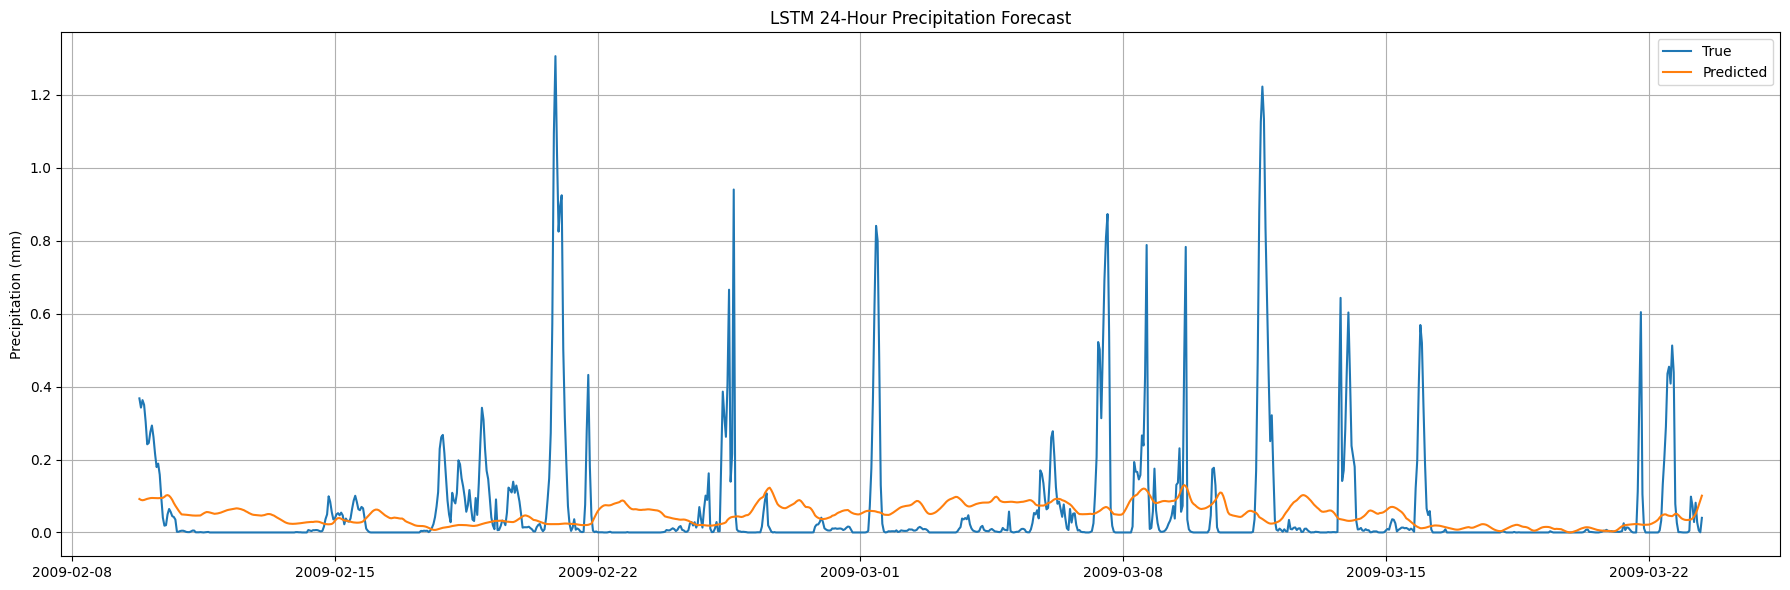

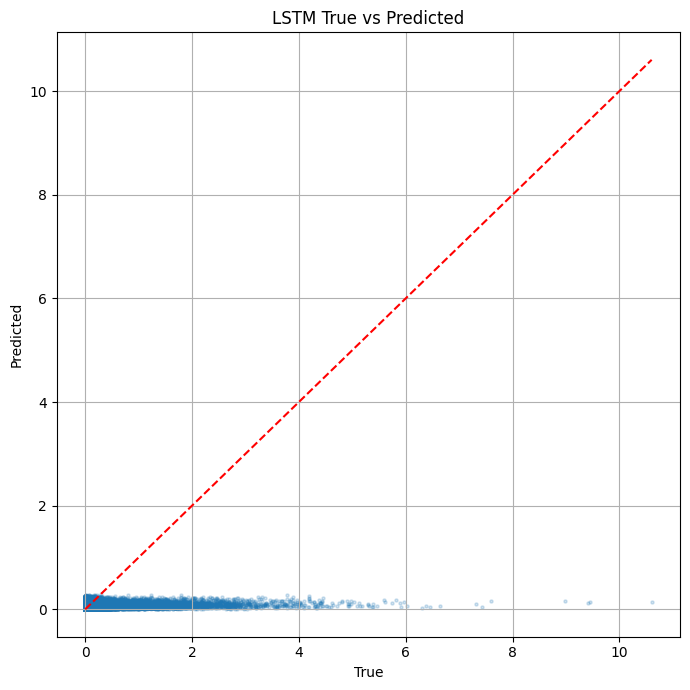

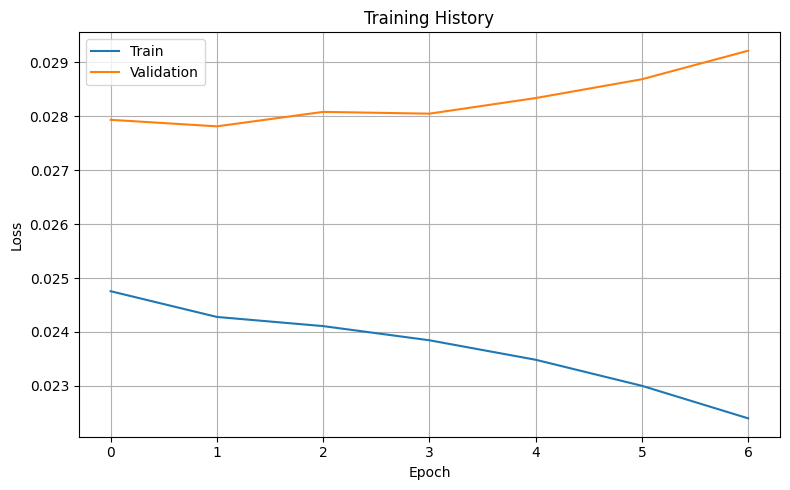

In [13]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


FORECAST_HORIZON = 24
SEQUENCE_LENGTH = 24


ds = xr.open_dataset(
    "single-point-timeseries_all_vars_1940-today_part1.nc"
)

df = ds.to_dataframe().sort_index()


df["t2m"] -= 273.15
df["d2m"] -= 273.15
df["tp"] *= 1000

df["wind10"] = np.sqrt(
    df["u10"]**2 +
    df["v10"]**2
)

df["wind100"] = np.sqrt(
    df["u100"]**2 +
    df["v100"]**2
)

df["RH"] = 100 * np.exp(
    (17.625 * df["d2m"]) /
    (243.04 + df["d2m"])
    -
    (17.625 * df["t2m"]) /
    (243.04 + df["t2m"])
)

df["hour"] = df.index.hour
df["dayofyear"] = df.index.dayofyear

df["hour_sin"] = np.sin(
    2*np.pi*df["hour"]/24
)

df["hour_cos"] = np.cos(
    2*np.pi*df["hour"]/24
)

df["doy_sin"] = np.sin(
    2*np.pi*df["dayofyear"]/365.25
)

df["doy_cos"] = np.cos(
    2*np.pi*df["dayofyear"]/365.25
)

features = [

    "t2m",
    "d2m",
    "RH",

    "u10",
    "v10",
    "u100",
    "v100",

    "wind10",
    "wind100",

    "fg10",

    "tcc",

    "sp",

    "blh",

    "strd",
    "ssrd",
    "fdir",

    "tp",

    "hour_sin",
    "hour_cos",

    "doy_sin",
    "doy_cos"
]

df = df[features].dropna()


target = np.log1p(
    df["tp"].shift(-FORECAST_HORIZON)
)

df["target"] = target

df = df.dropna()


feature_scaler = StandardScaler()

X_scaled = feature_scaler.fit_transform(
    df[features]
)


X = []
y = []

for i in range(SEQUENCE_LENGTH, len(df)):

    X.append(
        X_scaled[
            i-SEQUENCE_LENGTH:i
        ]
    )

    y.append(
        df["target"].iloc[i]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

n = len(X)

train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:]

y_train = y[:train_end]
y_val   = y[train_end:val_end]
y_test  = y[val_end:]

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(32)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(16, activation="relu")
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse"
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


lstm24_history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=10,

    batch_size=256,

    callbacks=[
        early_stop
    ],

    verbose=1
)


lstm24_preds_log = model.predict(
    X_test,
    verbose=0
).flatten()

lstm24_preds = np.expm1(
    lstm24_preds_log
)

lstm24_true = np.expm1(
    y_test
)

lstm24_preds = np.clip(
    lstm24_preds,
    0,
    None
)


lstm24_rmse = np.sqrt(
    mean_squared_error(
        lstm24_true,
        lstm24_preds
    )
)

lstm24_mae = mean_absolute_error(
    lstm24_true,
    lstm24_preds
)

lstm24_r2 = r2_score(
    lstm24_true,
    lstm24_preds
)

print("\n24-HOUR LSTM FORECAST\n")

print("RMSE:", lstm24_rmse)
print("MAE :", lstm24_mae)
print("R²  :", lstm24_r2)


test_index = df.index[
    SEQUENCE_LENGTH + val_end:
]

plot_df = pd.DataFrame(
    {
        "True": lstm24_true,
        "Predicted": lstm24_preds
    },
    index=test_index
)

plt.figure(
    figsize=(18,6)
)

plt.plot(
    plot_df.index[:1000],
    plot_df["True"][:1000],
    label="True"
)

plt.plot(
    plot_df.index[:1000],
    plot_df["Predicted"][:1000],
    label="Predicted"
)

plt.title(
    "LSTM 24-Hour Precipitation Forecast"
)

plt.ylabel(
    "Precipitation (mm)"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(7,7)
)

plt.scatter(
    lstm24_true,
    lstm24_preds,
    alpha=0.2,
    s=5
)

m = max(
    lstm24_true.max(),
    lstm24_preds.max()
)

plt.plot(
    [0,m],
    [0,m],
    "r--"
)

plt.xlabel(
    "True"
)

plt.ylabel(
    "Predicted"
)

plt.title(
    "LSTM True vs Predicted"
)

plt.grid(True)

plt.tight_layout()

plt.show()

plt.figure(
    figsize=(8,5)
)

plt.plot(
    lstm24_history.history["loss"],
    label="Train"
)

plt.plot(
    lstm24_history.history["val_loss"],
    label="Validation"
)

plt.title(
    "Training History"
)

plt.ylabel(
    "Loss"
)

plt.xlabel(
    "Epoch"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RAIN_THRESHOLD = 0.1

lstm24_true_rain = (
    lstm24_true > RAIN_THRESHOLD
).astype(int)

lstm24_pred_rain = (
    lstm24_preds > RAIN_THRESHOLD
).astype(int)

lstm24_accuracy = accuracy_score(
    lstm24_true_rain,
    lstm24_pred_rain
)

lstm24_precision = precision_score(
    lstm24_true_rain,
    lstm24_pred_rain,
    zero_division=0
)

lstm24_recall = recall_score(
    lstm24_true_rain,
    lstm24_pred_rain,
    zero_division=0
)

lstm24_f1 = f1_score(
    lstm24_true_rain,
    lstm24_pred_rain,
    zero_division=0
)

lstm24_cm = confusion_matrix(
    lstm24_true_rain,
    lstm24_pred_rain
)

print("\nLSTM 24-HOUR RAIN / NO-RAIN\n")

print("Accuracy :", lstm24_accuracy)
print("Precision:", lstm24_precision)
print("Recall   :", lstm24_recall)
print("F1 Score :", lstm24_f1)

print("\nConfusion Matrix:")
print(lstm24_cm)


LSTM 24-HOUR RAIN / NO-RAIN

Accuracy : 0.7922876291723068
Precision: 0.2623444976076555
Recall   : 0.25475073177531016
F1 Score : 0.25849185583292084

Confusion Matrix:
[[114505  15417]
 [ 16040   5483]]


X shape: (757247, 24, 21)
y shape: (757247,)


C:\Users\Vasileios\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - loss: 0.0155 - val_loss: 0.0155
Epoch 2/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - loss: 0.0132 - val_loss: 0.0143
Epoch 3/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 75s 42ms/step - loss: 0.0128 - val_loss: 0.0143
Epoch 4/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - loss: 0.0125 - val_loss: 0.0141
Epoch 5/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - loss: 0.0123 - val_loss: 0.0139
Epoch 6/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 79s 44ms/step - loss: 0.0121 - val_loss: 0.0137
Epoch 7/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - loss: 0.0120 - val_loss: 0.0137
Epoch 8/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 87s 47ms/step - loss: 0.0119 - val_loss: 0.0138
Epoch 9/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - loss: 0.0118 - val_loss: 0.0138
Epoch 10/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 136s 43ms/step - loss: 0.0117 - val_loss: 0.0139

1-HOUR GRU FORECAST

RMSE: 0.23397365220708125
MAE : 0.07042887806892395
R²  : 0.3930635452270508

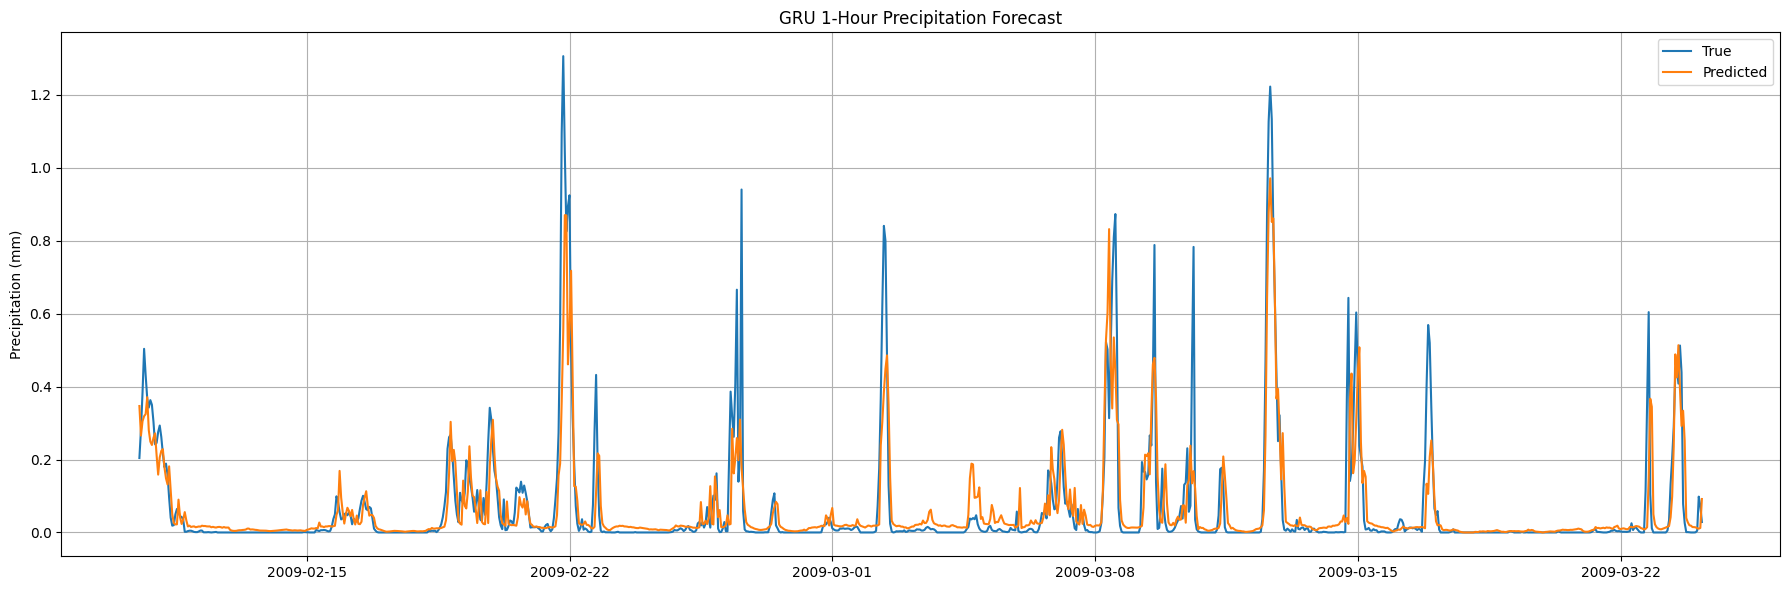

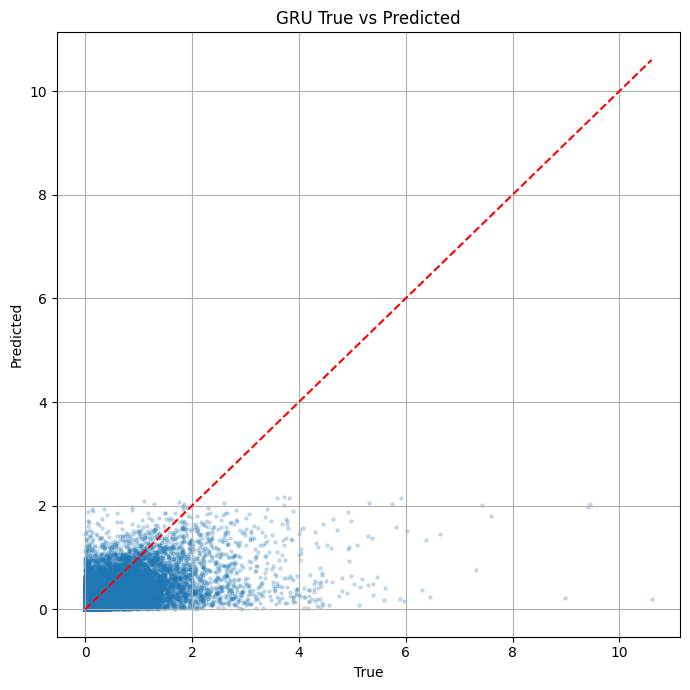

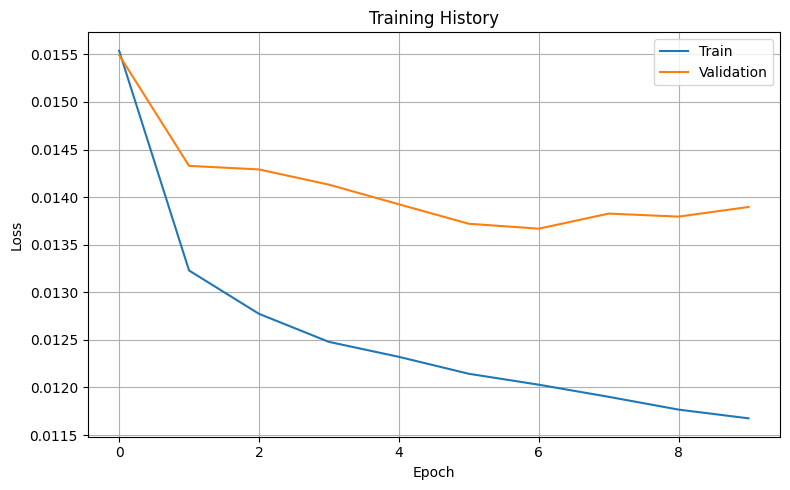

In [15]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


FORECAST_HORIZON = 1
SEQUENCE_LENGTH = 24


ds = xr.open_dataset(
    "single-point-timeseries_all_vars_1940-today_part1.nc"
)

df = ds.to_dataframe().sort_index()

df["t2m"] -= 273.15
df["d2m"] -= 273.15
df["tp"] *= 1000


df["wind10"] = np.sqrt(
    df["u10"]**2 +
    df["v10"]**2
)

df["wind100"] = np.sqrt(
    df["u100"]**2 +
    df["v100"]**2
)

df["RH"] = 100 * np.exp(
    (17.625 * df["d2m"]) /
    (243.04 + df["d2m"])
    -
    (17.625 * df["t2m"]) /
    (243.04 + df["t2m"])
)


df["hour"] = df.index.hour
df["dayofyear"] = df.index.dayofyear

df["hour_sin"] = np.sin(
    2*np.pi*df["hour"]/24
)

df["hour_cos"] = np.cos(
    2*np.pi*df["hour"]/24
)

df["doy_sin"] = np.sin(
    2*np.pi*df["dayofyear"]/365.25
)

df["doy_cos"] = np.cos(
    2*np.pi*df["dayofyear"]/365.25
)


features = [

    "t2m",
    "d2m",
    "RH",

    "u10",
    "v10",
    "u100",
    "v100",

    "wind10",
    "wind100",

    "fg10",

    "tcc",

    "sp",

    "blh",

    "strd",
    "ssrd",
    "fdir",

    "tp",

    "hour_sin",
    "hour_cos",

    "doy_sin",
    "doy_cos"
]

df = df[features].dropna()


target = np.log1p(
    df["tp"].shift(-FORECAST_HORIZON)
)

df["target"] = target

df = df.dropna()


feature_scaler = StandardScaler()

X_scaled = feature_scaler.fit_transform(
    df[features]
)


X = []
y = []

for i in range(SEQUENCE_LENGTH, len(df)):

    X.append(
        X_scaled[
            i-SEQUENCE_LENGTH:i
        ]
    )

    y.append(
        df["target"].iloc[i]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

n = len(X)

train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:]

y_train = y[:train_end]
y_val   = y[train_end:val_end]
y_test  = y[val_end:]


model = Sequential()

model.add(
    GRU(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    GRU(32)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(16, activation="relu")
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse"
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


gru1_history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=10,

    batch_size=256,

    callbacks=[
        early_stop
    ],

    verbose=1
)

gru1_preds_log = model.predict(
    X_test,
    verbose=0
).flatten()

gru1_preds = np.expm1(
    gru1_preds_log
)

gru1_true = np.expm1(
    y_test
)

gru1_preds = np.clip(
    gru1_preds,
    0,
    None
)



gru1_rmse = np.sqrt(
    mean_squared_error(
        gru1_true,
        gru1_preds
    )
)

gru1_mae = mean_absolute_error(
    gru1_true,
    gru1_preds
)

gru1_r2 = r2_score(
    gru1_true,
    gru1_preds
)

print("\n1-HOUR GRU FORECAST\n")

print("RMSE:", gru1_rmse)
print("MAE :", gru1_mae)
print("R²  :", gru1_r2)



test_index = df.index[
    SEQUENCE_LENGTH + val_end:
]

plot_df = pd.DataFrame(
    {
        "True": gru1_true,
        "Predicted": gru1_preds
    },
    index=test_index
)

plt.figure(
    figsize=(18,6)
)

plt.plot(
    plot_df.index[:1000],
    plot_df["True"][:1000],
    label="True"
)

plt.plot(
    plot_df.index[:1000],
    plot_df["Predicted"][:1000],
    label="Predicted"
)

plt.title(
    "GRU 1-Hour Precipitation Forecast"
)

plt.ylabel(
    "Precipitation (mm)"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(7,7)
)

plt.scatter(
    gru1_true,
    gru1_preds,
    alpha=0.2,
    s=5
)

m = max(
    gru1_true.max(),
    gru1_preds.max()
)

plt.plot(
    [0,m],
    [0,m],
    "r--"
)

plt.xlabel(
    "True"
)

plt.ylabel(
    "Predicted"
)

plt.title(
    "GRU True vs Predicted"
)

plt.grid(True)

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(8,5)
)

plt.plot(
    gru1_history.history["loss"],
    label="Train"
)

plt.plot(
    gru1_history.history["val_loss"],
    label="Validation"
)

plt.title(
    "Training History"
)

plt.ylabel(
    "Loss"
)

plt.xlabel(
    "Epoch"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RAIN_THRESHOLD = 0.1

gru1_true_rain = (
    gru1_true > RAIN_THRESHOLD
).astype(int)

gru1_pred_rain = (
    gru1_preds > RAIN_THRESHOLD
).astype(int)

gru1_accuracy = accuracy_score(
    gru1_true_rain,
    gru1_pred_rain
)

gru1_precision = precision_score(
    gru1_true_rain,
    gru1_pred_rain,
    zero_division=0
)

gru1_recall = recall_score(
    gru1_true_rain,
    gru1_pred_rain,
    zero_division=0
)

gru1_f1 = f1_score(
    gru1_true_rain,
    gru1_pred_rain,
    zero_division=0
)

gru1_cm = confusion_matrix(
    gru1_true_rain,
    gru1_pred_rain
)

print("\n1-HOUR GRU RAIN / NO-RAIN\n")

print("Accuracy :", gru1_accuracy)
print("Precision:", gru1_precision)
print("Recall   :", gru1_recall)
print("F1 Score :", gru1_f1)

print("\nConfusion Matrix:")
print(gru1_cm)


1-HOUR GRU RAIN / NO-RAIN

Accuracy : 0.8969758996368439
Precision: 0.6161810267069296
Recall   : 0.7298402081010776
F1 Score : 0.6682118782826887

Confusion Matrix:
[[120135   9787]
 [  5816  15712]]


X shape: (757224, 24, 21)
y shape: (757224,)


C:\Users\Vasileios\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - loss: 0.0258 - val_loss: 0.0280
Epoch 2/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - loss: 0.0244 - val_loss: 0.0280
Epoch 3/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 76s 43ms/step - loss: 0.0243 - val_loss: 0.0280
Epoch 4/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 97s 51ms/step - loss: 0.0243 - val_loss: 0.0279
Epoch 5/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 76s 43ms/step - loss: 0.0241 - val_loss: 0.0279
Epoch 6/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 85s 44ms/step - loss: 0.0240 - val_loss: 0.0280
Epoch 7/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - loss: 0.0238 - val_loss: 0.0280
Epoch 8/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - loss: 0.0235 - val_loss: 0.0281
Epoch 9/10
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 86s 49ms/step - loss: 0.0231 - val_loss: 0.0286

24-HOUR GRU FORECAST

RMSE: 0.2984066777515372
MAE : 0.10498864948749542
R²  : 0.0127524733543396


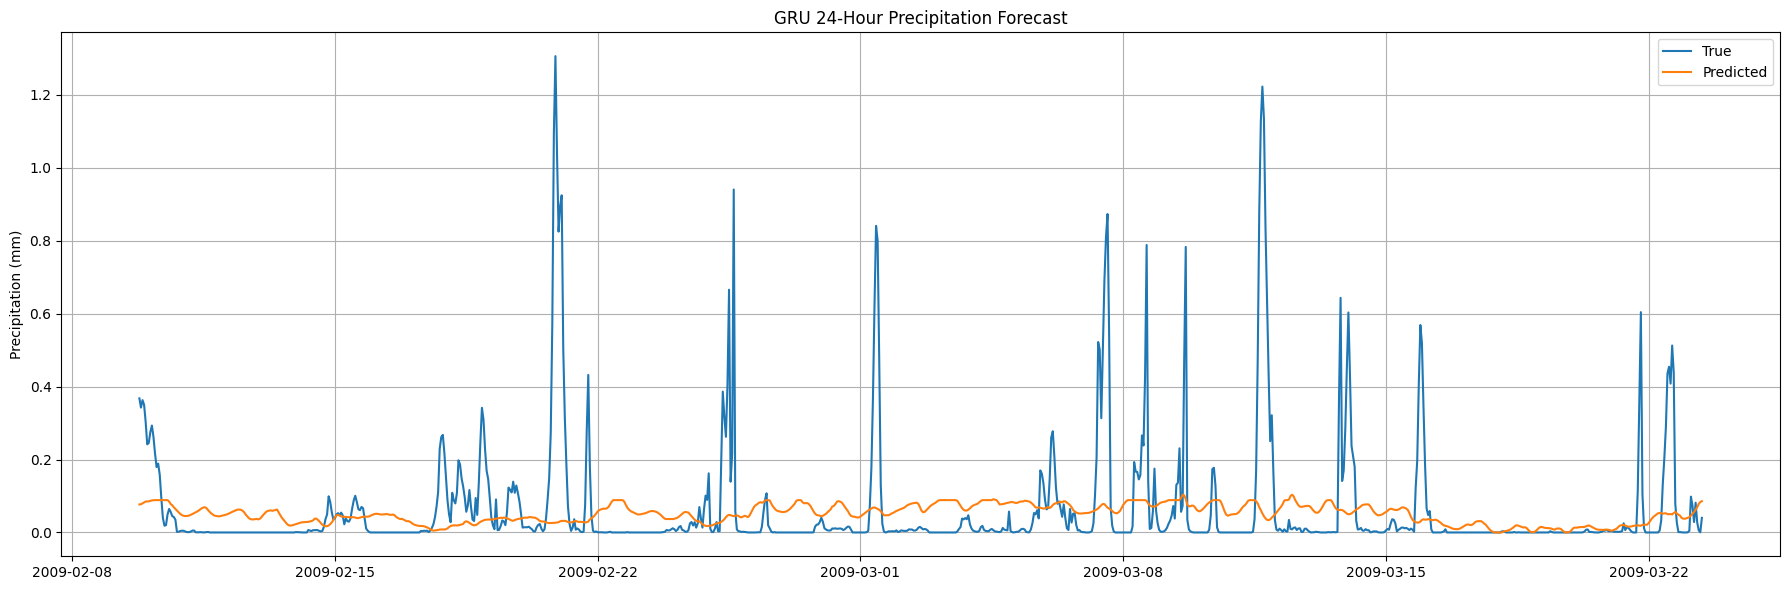

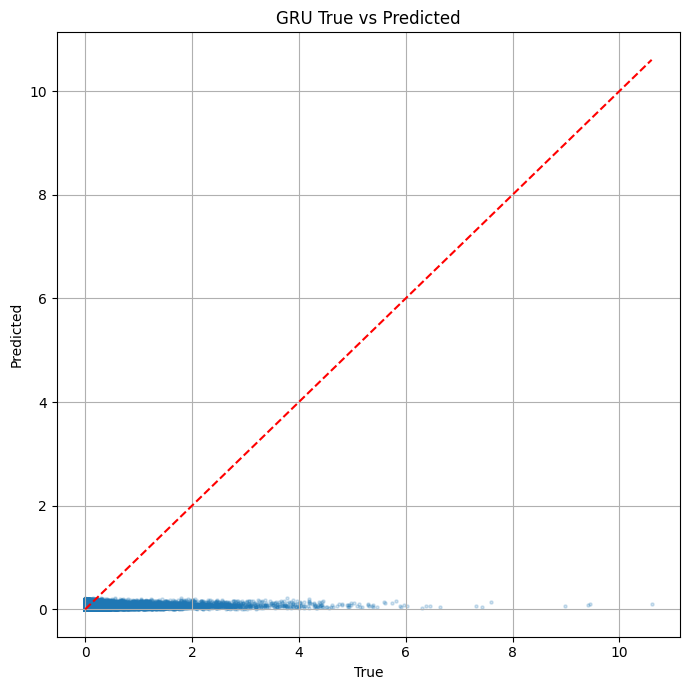

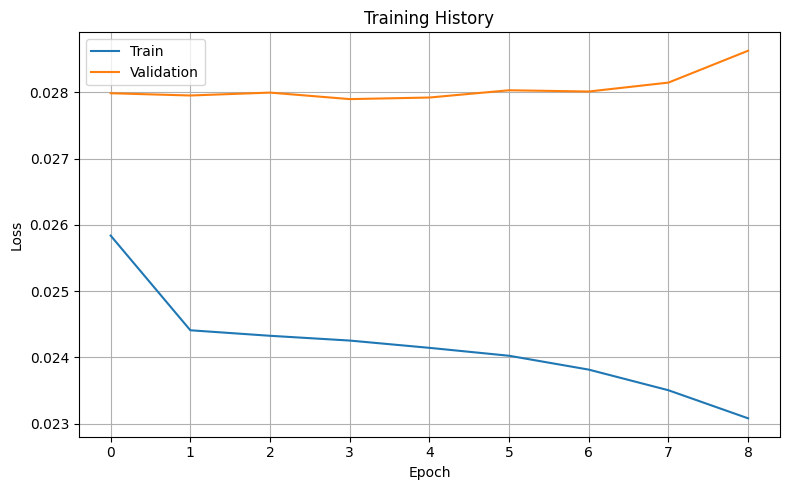

In [18]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


FORECAST_HORIZON = 24
SEQUENCE_LENGTH = 24


ds = xr.open_dataset(
    "single-point-timeseries_all_vars_1940-today_part1.nc"
)

df = ds.to_dataframe().sort_index()


df["t2m"] -= 273.15
df["d2m"] -= 273.15
df["tp"] *= 1000


df["wind10"] = np.sqrt(
    df["u10"]**2 +
    df["v10"]**2
)

df["wind100"] = np.sqrt(
    df["u100"]**2 +
    df["v100"]**2
)

df["RH"] = 100 * np.exp(
    (17.625 * df["d2m"]) /
    (243.04 + df["d2m"])
    -
    (17.625 * df["t2m"]) /
    (243.04 + df["t2m"])
)


df["hour"] = df.index.hour
df["dayofyear"] = df.index.dayofyear

df["hour_sin"] = np.sin(
    2*np.pi*df["hour"]/24
)

df["hour_cos"] = np.cos(
    2*np.pi*df["hour"]/24
)

df["doy_sin"] = np.sin(
    2*np.pi*df["dayofyear"]/365.25
)

df["doy_cos"] = np.cos(
    2*np.pi*df["dayofyear"]/365.25
)


features = [

    "t2m",
    "d2m",
    "RH",

    "u10",
    "v10",
    "u100",
    "v100",

    "wind10",
    "wind100",

    "fg10",

    "tcc",

    "sp",

    "blh",

    "strd",
    "ssrd",
    "fdir",

    "tp",

    "hour_sin",
    "hour_cos",

    "doy_sin",
    "doy_cos"
]

df = df[features].dropna()


target = np.log1p(
    df["tp"].shift(-FORECAST_HORIZON)
)

df["target"] = target

df = df.dropna()


feature_scaler = StandardScaler()

X_scaled = feature_scaler.fit_transform(
    df[features]
)


X = []
y = []

for i in range(SEQUENCE_LENGTH, len(df)):

    X.append(
        X_scaled[
            i-SEQUENCE_LENGTH:i
        ]
    )

    y.append(
        df["target"].iloc[i]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


n = len(X)

train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:]

y_train = y[:train_end]
y_val   = y[train_end:val_end]
y_test  = y[val_end:]


model = Sequential()

model.add(
    GRU(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    GRU(32)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(16, activation="relu")
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse"
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


gru24_history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=10,

    batch_size=256,

    callbacks=[
        early_stop
    ],

    verbose=1
)


gru24_preds_log = model.predict(
    X_test,
    verbose=0
).flatten()

gru24_preds = np.expm1(
    gru24_preds_log
)

gru24_true = np.expm1(
    y_test
)

gru24_preds = np.clip(
    gru24_preds,
    0,
    None
)


gru24_rmse = np.sqrt(
    mean_squared_error(
        gru24_true,
        gru24_preds
    )
)

gru24_mae = mean_absolute_error(
    gru24_true,
    gru24_preds
)

gru24_r2 = r2_score(
    gru24_true,
    gru24_preds
)

print("\n24-HOUR GRU FORECAST\n")

print("RMSE:", gru24_rmse)
print("MAE :", gru24_mae)
print("R²  :", gru24_r2)


test_index = df.index[
    SEQUENCE_LENGTH + val_end:
]

plot_df = pd.DataFrame(
    {
    "True": gru24_true,
    "Predicted": gru24_preds
},
    index=test_index
)

plt.figure(
    figsize=(18,6)
)

plt.plot(
    plot_df.index[:1000],
    plot_df["True"][:1000],
    label="True"
)

plt.plot(
    plot_df.index[:1000],
    plot_df["Predicted"][:1000],
    label="Predicted"
)

plt.title(
    "GRU 24-Hour Precipitation Forecast"
)

plt.ylabel(
    "Precipitation (mm)"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(7,7)
)

plt.scatter(
    gru24_true,
    gru24_preds,
    alpha=0.2,
    s=5
)

m = max(
    gru24_true.max(),
    gru24_preds.max()
)

plt.plot(
    [0,m],
    [0,m],
    "r--"
)

plt.xlabel(
    "True"
)

plt.ylabel(
    "Predicted"
)

plt.title(
    "GRU True vs Predicted"
)

plt.grid(True)

plt.tight_layout()

plt.show()


plt.figure(
    figsize=(8,5)
)

plt.plot(
    gru24_history.history["loss"],
    label="Train"
)

plt.plot(
    gru24_history.history["val_loss"],
    label="Validation"
)

plt.title(
    "Training History"
)

plt.ylabel(
    "Loss"
)

plt.xlabel(
    "Epoch"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

Accuracy : 0.8240747466076793
Precision: 0.2616387337057728
Recall   : 0.13055800771267945
F1 Score : 0.1741933484176921

Confusion Matrix:
[[121992   7930]
 [ 18713   2810]]


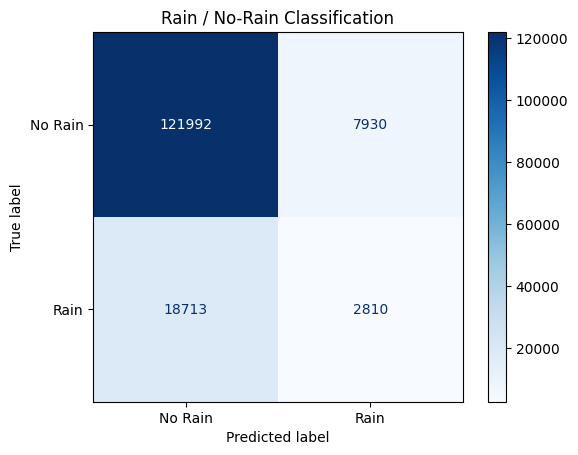

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RAIN_THRESHOLD = 0.1  # mm

true_rain = (true_test > RAIN_THRESHOLD).astype(int)
pred_rain = (preds_test > RAIN_THRESHOLD).astype(int)

acc = accuracy_score(true_rain, pred_rain)
prec = precision_score(true_rain, pred_rain)
rec = recall_score(true_rain, pred_rain)
f1 = f1_score(true_rain, pred_rain)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

cm = confusion_matrix(true_rain, pred_rain)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Rain", "Rain"]
)

disp.plot(cmap="Blues")
plt.title("Rain / No-Rain Classification")
plt.show()